##Syllabus Machine Learning II

**Week 9: Self-organizing maps (SOMs)**

*   Definition of SOMs
*   Training a SOM
*   Applications of SOMs

In [ ]:
# Mount Drive files
from google.colab import drive
import sys, os

# Uncomment for mounting drive files
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
# Install minisom if needed
!pip install minisom

  Preparing metadata (setup.py) ... done
  Created wheel for minisom: filename=MiniSom-2.3.6-py3-none-any.whl size=13083 sha256=e638bded9f9462e92426cf3be967dc671a0358815093f48e72c8ccdded577e52
  Stored in directory: /root/.cache/pip/wheels/84/35/b8/48b06bd8cae7187916c28a29c6daa9e0ff610647a2dfa62b97
Successfully built minisom


In [ ]:
!cp -r "/content/gdrive/MyDrive/Colab Notebooks/Machine Learning II/Week 6/utils.py" /content
!cp -r "/content/gdrive/MyDrive/Colab Notebooks/Machine Learning II/Week 6/data" /content/data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from minisom import MiniSom
import math

# Sklearn auxiliary items
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from utils import (
    build_lattice,
    plot_neurons_distances,
    visualize_data_points_grid,
    classify,
    plot_feature_influence,
    plot_most_important_variable,
    train_plot_som
)

# Matplotlib Options
plt.rcParams['figure.figsize'] = [16, 8]
font = {'weight' : 'bold',
        'size'   : 14}
plt.rc('font', **font)

# Pandas options
pd.set_option("display.max_columns", None)

# Self Organizing Maps - Walkthrough

Before we start, huge shoutout to @[JustGlowing](https://github.com/JustGlowing) for the awesome `minisom` package.

**Self-Organizing Maps (SOMs) are a type of unsupervised neural network that is used for dimensionality reduction** and visualization of high-dimensional data. SOMs are trained using a competitive learning algorithm, in which nodes (also known as neurons) in the network compete for the right to represent input data.
<br>
<br>
The SOM architecture consists of a 2D grid of nodes, where each node is associated with a weight vector that represents a point in the input space. The nodes are organized in such a way that similar input data is mapped to nearby nodes in the SOM.
<br>
<br>
SOMs are commonly used for tasks such as data visualization, anomaly detection, and feature extraction.

In a nutshell, SOMs are the neural network version of unsupervised learning!

In [ ]:
# Let's build a simple toy example for this step-by-step implementation.
X = np.array([[1, 2], [2, 1], [1, 3], [1, 2.5], [3.1, 5], [4, 10], [3.6, 5.4], [2, 3]])

Let's visualize our data:

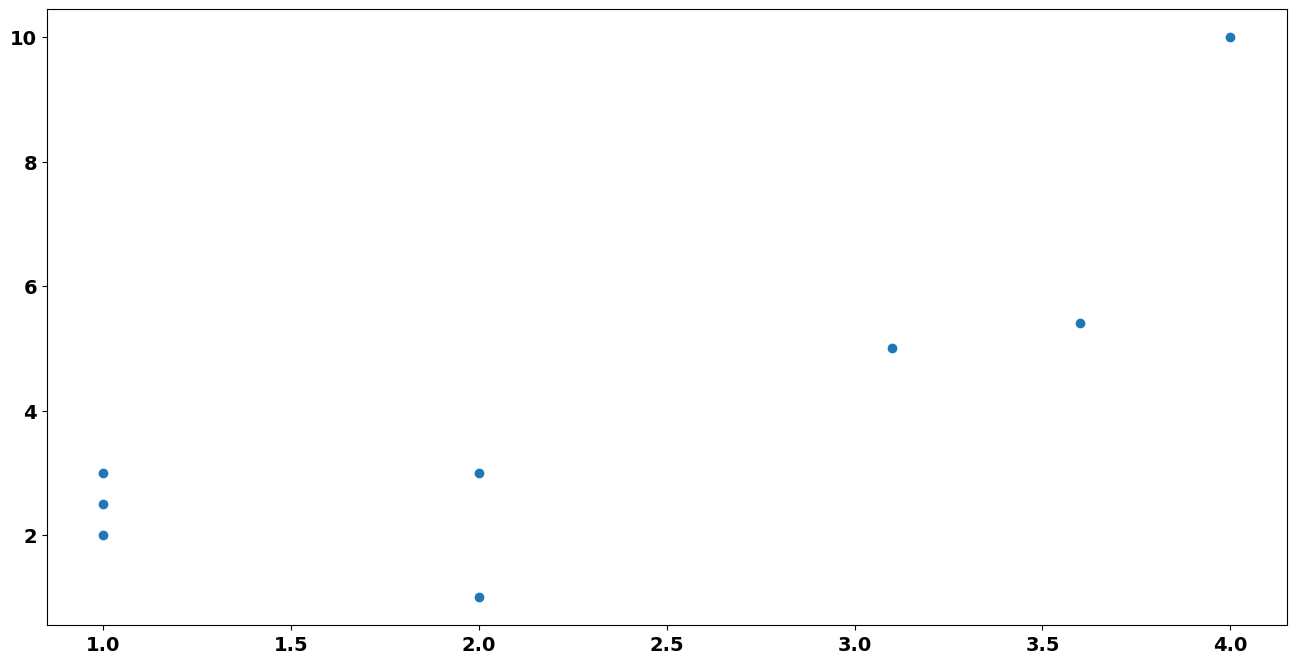

In [ ]:
plt.scatter(X[:,0], X[:,1])

Self-orgazining maps project our data into a 2-D space. **It is (kind-of) considered a one-layer neural network without any target. SOM's showed up in the 70's before backpropagation was a thing:**

![som](https://miro.medium.com/max/1400/1*Gf70S1DYJyhq_mVzXr3G7Q.png)

Let's define that our map contains 4 neurons (or processing units, as they were originally called..) and space them in our 2-D plot, equally distributed:

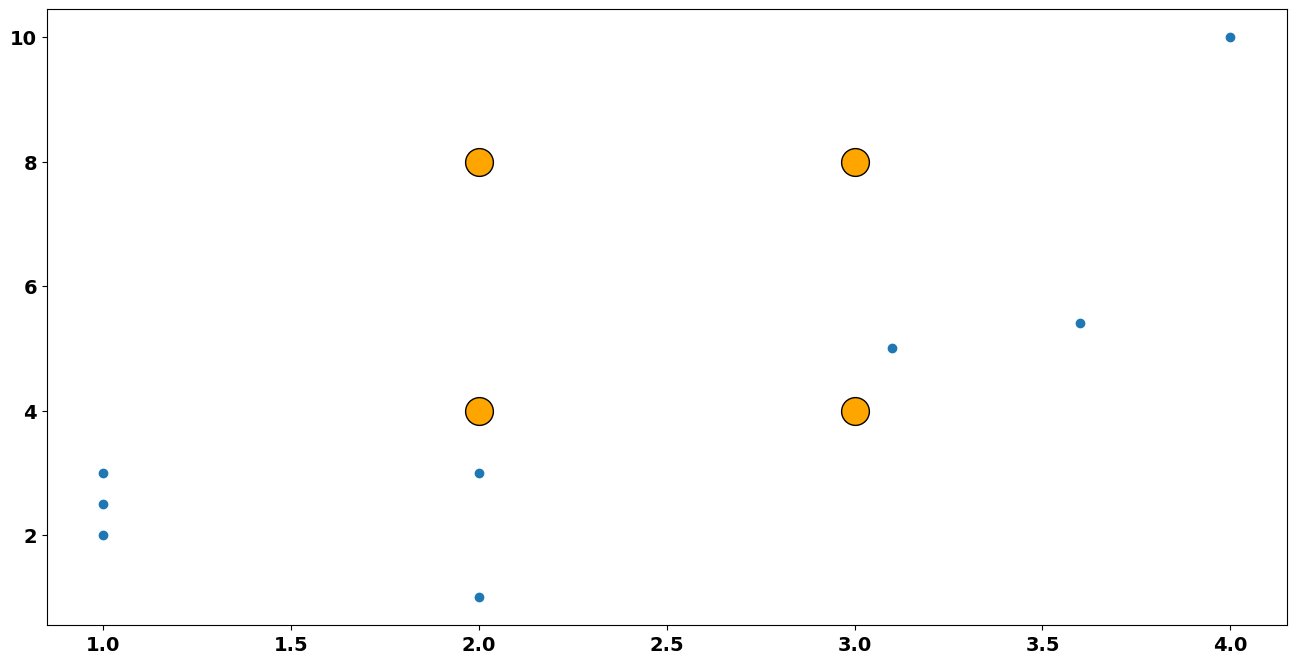

In [ ]:
plt.scatter(X[:,0], X[:,1])
neurons = [[2,4], [2,8], [3,4], [3,8]]

for neuron in neurons:
  plt.scatter(neuron[0], neuron[1], c='orange', s=400, edgecolor='black')

We start by picking up a point (again, as in other algorithms 🙂) and checking the euclidean distance between the point and each `neuron` - let me pick up this data point:

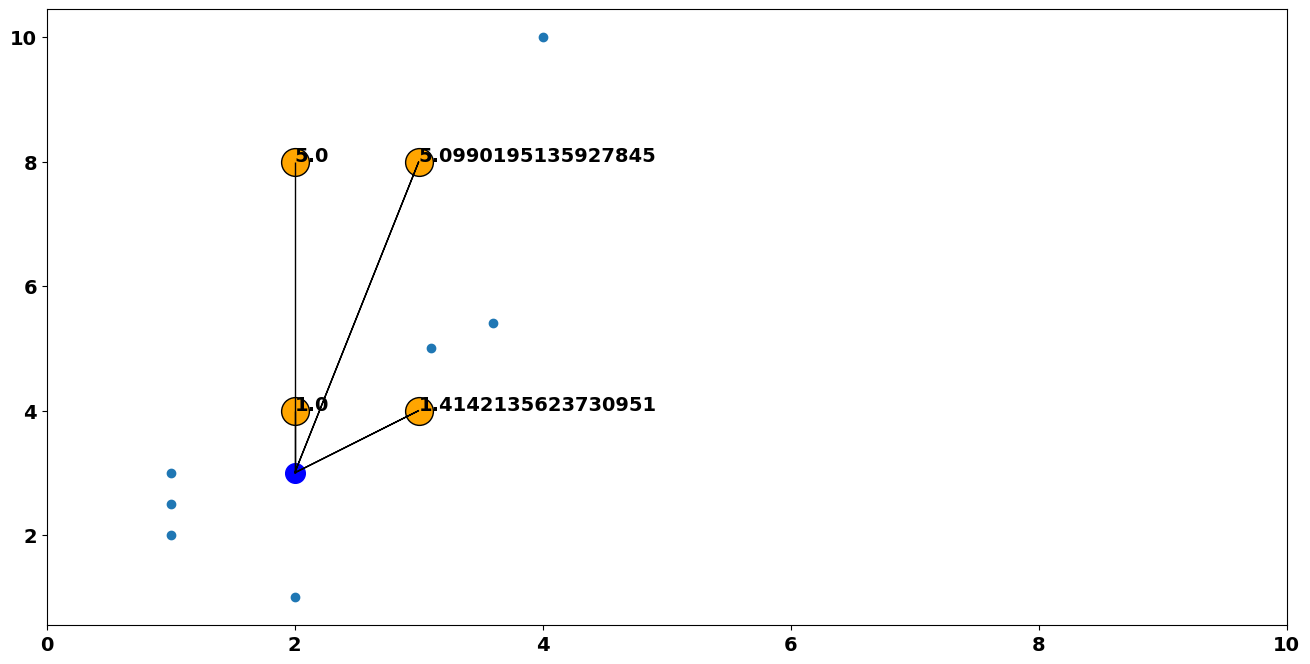

In [ ]:
plot_neurons_distances(X, neurons, [2,3], [2,3])

The point we are using is highlighted in blue - the winning neuron is the one with the lowest distance - also called **Best Match Unit**. We need to update this neuron and bring it closer to our point - a novelty regarding *k-means* is that not only the winning "neuron" is updated, but also the neighboring ones.

And.. how do we define what are the neighbors? Via a gaussian function with a kernel function that is equal to $e^{-\frac{||x-y||^2}{2\sigma^2}}$. I'm going to call this formula $howfar$.
<br>
<br>
**Let's take it slowly** - basically, this function will translate into the distance between our winning node and the neighbors. For example, let's consider our winning node and the difference (squared distance) between itself and the other neurons:

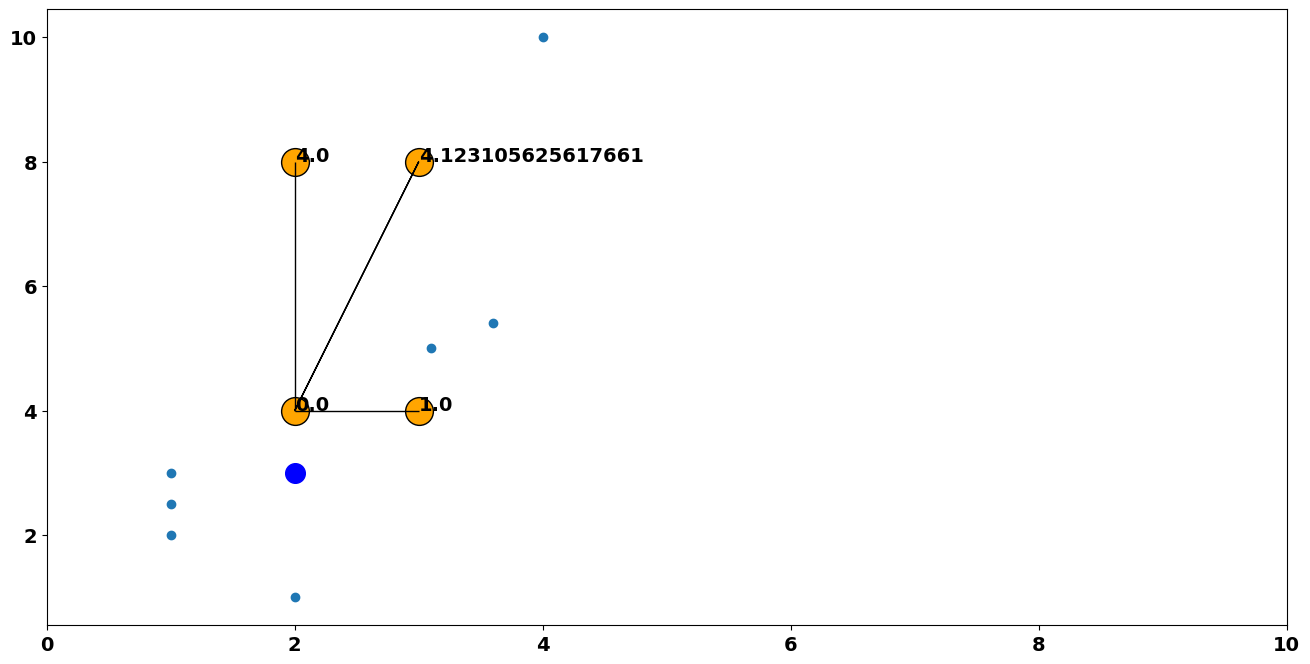

In [ ]:
plot_neurons_distances(X, neurons, [2,3], [2,4])

In the $howfar$ formula, $\sigma$ is an hyperparameter (given by the user). I'm going to choose $\sigma=1$ for the first experiment.
<br>
<br>
Between our winning node and the node to the right, the $howfar$ is $e^{-\frac{1^2}{2*1^2}}$, which is `0.7788007830714049`. If I raise sigma? $howfar$ is $e^{-\frac{1^2}{2*2^2}}$ which is `0.9394130628134758` and this node will be updated more strongly!
<br>
<br>
$howfar$ will be one of the components that will update our weights (erhem.. centroids?). If $\sigma$ is bigger, then we consider that we allow more influence from the winning neuron to its neighbors.

Let's settle on $\sigma=1$ and $howfar$ between the bottom nodes as `0.7788007830714049`.
<br>
<br>
Now, let's calculate $howfar$ between our winning neuron (or node, I'm intertwining between the two) and the one that sits on the top right corner. The only things that changes in our formula is the distance: $e^{-\frac{4.123^2}{1*1^2}}$. This will yield: `0.014267340284127246`

Notice how $howfar$ is much smaller between these nodes! Why? Because the distance between them is much larger!

Finally, the $howfar$ between our winning node and the one that sits on top of it is: $e^{-\frac{4^2}{1*1^2}}$. This will yield: `0.01831563888873418`

In summary:

| Node 1     | Node 2 | $howfar$ |
|--------------|-----|--------|
| Winner (Bottom-left)     | Bottom-right   | 0.7788007830714049   |
| Winner (Bottom-left)     | Top-right   | 0.014267340284127246   |
| Winner (Bottom-left)     | Top-Left   | 0.01831563888873418   |

Nice! So, now I can reveal how we can update the weights - the formula is basically:
$w_{i,k} = w_{i,k} + howfar*learningrate*(x_i-w_{i,k})$.
<br>
<br>
So, basically - the weight variable $i$ for node $k$ will be equal to the existing weight plus or minus (depending on if we are updating our node to the left or right of the data point that originated the winner) an adjustment that is multiplied by $howfar$ and the $learningrate$.

Like most learning rates in neural networks.. this one is an hyperparameter as well 😖. Let me now extend our table to present how this formula will impact each of our neurons in the SOM - remember that we need to update both `x` and `y`:

| Variable &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; | Node 1 &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; | Node 2 &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; | $h(dist)$ &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; | $\alpha$ (lr) &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; | $x_i - w_{i,k}$ &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; | Update Value &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; |
|---|---|---|---|---|---|---|
| **Variable 1 (x-axis)** | Winner (Bottom-left) | Bottom-right &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; | 0.7788 &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; | 0.2 &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; | -1 &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; | $3 + 3 \times 0.779 \times 0.2 \times (-1) = 2.530$ &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; |
| **Variable 1 (x-axis)** | Winner (Bottom-left) | Top-right &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; | 0.0143 &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; | 0.2 &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; | -1 &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; | $3 + 3 \times 0.0142 \times 0.2 \times (-1) = 2.992$ &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; |
| **Variable 1 (x-axis)** | Winner (Bottom-left) | Top-left &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; | 0.0183 &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; | 0.2 &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; | 0 &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; | $2 + 2 \times 0.0183 \times 0.2 \times 0 = 2.000$ &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; |
| **Variable 2 (y-axis)** | Winner (Bottom-left) | Bottom-right &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; | 0.7788 &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; | 0.2 &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; | -1 &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; | $4 + 4 \times 0.779 \times 0.2 \times (-1) = 3.377$ &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; |
| **Variable 2 (y-axis)** | Winner (Bottom-left) | Top-right &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; | 0.0143 &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; | 0.2 &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; | -5 &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; | $8 + 8 \times 0.01427 \times 0.2 \times (-5) = 7.889$ &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; |
| **Variable 2 (y-axis)** | Winner (Bottom-left) | Top-left &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; | 0.0183 &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; | 0.2 &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; | -5 &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; | $8 + 8 \times 0.01832 \times 0.2 \times (-5) = 7.854$ &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; |

We now have the coordinates for our new nodes in our self organizing map! Basically:
* The bottom-right node will sit on point [2.53, 3.377]
* The top-right node will sit on point [2.992, 7.889]
* The top-left node will sit on point [2, 7.854]

But.. if all points move, what happens to our winning node? Isn't it unfair that all points in the SOM move except our winning node?
<br>
<br>
It is! And that's why our winning node will move and will be the one that will move the most. Why? Because $howfar=1$ for this one will be 1 (as distance is equal to 0). Let's plug those values for our winning node below:

| Variable | Node 1 | Node 2 | h(dist) | α (lr) | $x_i - w_{i,k}$ | Update Value |
|---|---|---|---|---|---|---|
| **Variable 1 (x-axis)** | Winner (Bottom-left) | Winner (Bottom-left) | 1 &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; | 0.2 &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; | 0 &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; | $2 + 2 \times 1 \times 0.2 \times 0 = 2.000$ &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; |
| **Variable 2 (y-axis)** | Winner (Bottom-left) | Winner (Bottom-left) | 1 &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; | 0.2 &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; | -1 &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; | $4 + 4 \times 1 \times 0.2 \times (-1) = 3.2$ &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; |

The new coordinates of our winning node are [2, 3.2]!

In [ ]:
new_neurons = [[2.53, 3.377], [2.992, 7.889], [2, 7.854], [2, 3.2]]

So let's now see how our Self Organizing Map errrr.. organized itself!

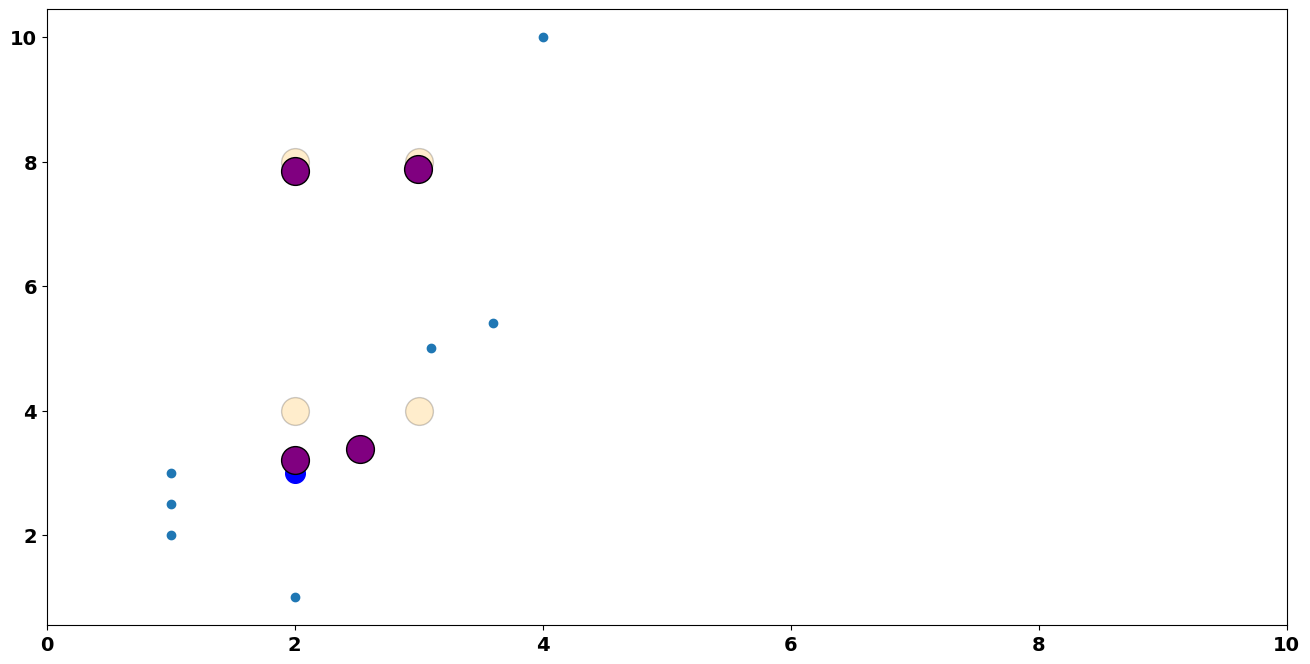

In [ ]:
# Plotting new neurons

fig, ax = plt.subplots()

plt.xlim(0, 10)
plt.scatter(X[:,0], X[:,1])
plt.scatter(2, 3, s=200, c='blue')
for neuron in neurons:
  plt.scatter(neuron[0], neuron[1], c='orange', s=400, edgecolor='black', alpha=0.2)

for neuron in new_neurons:
  plt.scatter(neuron[0], neuron[1], c='purple', s=400, edgecolor='black')


We continue to do this for several epochs. 1 epoch is considered a pass through the entire dataset, where the network organizes itself until it mimics the underlying points as much as possible.
<br>
<br>


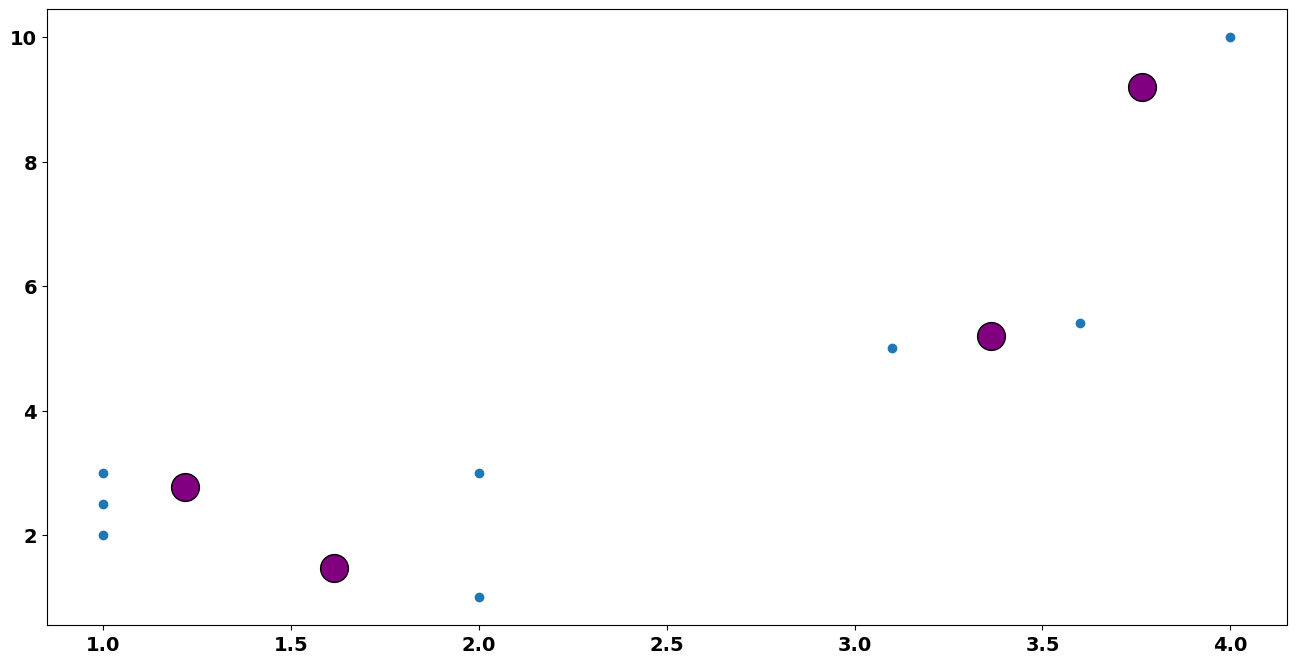

In [ ]:
train_plot_som(X)

Some important details about the algorithm:
*   Learning rate may decay over time.
*   Sigma typically decays over time as well.
*   There's no "function" to minimize or maximize. Although distance between neurons and underlying points is a proxy. That's why we need to provide a number of epochs for training.

Here's a cool visualization of the training process going forward:

![somtraining](https://upload.wikimedia.org/wikipedia/commons/3/35/TrainSOM.gif)

# Practical Example! (With some learnings on Stock investing, too 💸)

As usual, let's approach our algorithms with a practical example. This time, we will be working as a financial analyst at a stock investing company.
<br>
<br>
Basically, we have a dataset of several companies in the S&P 500, with information about their valuation and financial information.

In [ ]:
financial_valuation_data = pd.read_csv('/content/data/constituents-financials_csv.csv')

In [ ]:
financial_valuation_data.head(10)

,Symbol,Name,Sector,Price,Price/Earnings,Dividend Yield,Earnings/Share,52 Week Low,52 Week High,Market Cap,EBITDA,Price/Sales,Price/Book,SEC Filings
0,MMM,3M Company,Industrials,222.89,24.31,2.332862,7.92,259.770,175.490,138721055226,9.048000e+09,4.390271,11.34,http://www.sec.gov/cgi-bin/browse-edgar?action...
1,AOS,A.O. Smith Corp,Industrials,60.24,27.76,1.147959,1.70,68.390,48.925,10783419933,6.010000e+08,3.575483,6.35,http://www.sec.gov/cgi-bin/browse-edgar?action...
2,ABT,Abbott Laboratories,Health Care,56.27,22.51,1.908982,0.26,64.600,42.280,102121042306,5.744000e+09,3.740480,3.19,http://www.sec.gov/cgi-bin/browse-edgar?action...
3,ABBV,AbbVie Inc.,Health Care,108.48,19.41,2.499560,3.29,125.860,60.050,181386347059,1.031000e+10,6.291571,26.14,http://www.sec.gov/cgi-bin/browse-edgar?action...
4,ACN,Accenture plc,Information Technology,150.51,25.47,1.714470,5.44,162.600,114.820,98765855553,5.643228e+09,2.604117,10.62,http://www.sec.gov/cgi-bin/browse-edgar?action...
5,ATVI,Activision Blizzard,Information Technology,65.83,31.80,0.431903,1.28,74.945,38.930,52518668144,2.704000e+09,10.595120,5.16,http://www.sec.gov/cgi-bin/browse-edgar?action...
6,AYI,Acuity Brands Inc,Industrials,145.41,18.22,0.351185,7.43,225.360,142.000,6242377704,5.878000e+08,1.795347,3.55,http://www.sec.gov/cgi-bin/browse-edgar?action...
7,ADBE,Adobe Systems Inc,Information Technology,185.16,52.31,0.000000,3.39,204.450,114.451,94550214268,2.538040e+09,13.092818,11.06,http://www.sec.gov/cgi-bin/browse-edgar?action...
8,AAP,Advance Auto Parts,Consumer Discretionary,109.63,19.54,0.218321,6.19,169.550,78.810,8123611867,8.539410e+08,1.130106,2.51,http://www.sec.gov/cgi-bin/browse-edgar?action...
9,AMD,Advanced Micro Devices Inc,Information Technology,11.22,187.00,0.000000,0.03,15.650,9.700,11191663795,3.390000e+08,2.109195,21.47,http://www.sec.gov/cgi-bin/browse-edgar?action...


In [ ]:
# Create feature of volatity
financial_valuation_data['Volatility'] = (
    financial_valuation_data['52 Week High']-financial_valuation_data['52 Week Low']
    )/financial_valuation_data['52 Week High']

We would like to understand how these factors interact between themselves:
*  Can we use financials and valuation data to group companies together?
*  Are we able to train a SOM that "more-or-less" encapsulates the Sector of the company?
*  Can we find outliers using our SOM?

In [ ]:
# Subsetting the variables of interest

financial_valuation_data_subset = (
    financial_valuation_data[['Price/Earnings','Dividend Yield','Earnings/Share','Price/Sales', 'Price/Book', 'Volatility']]
)

Our training data consists of the following features:
*  `Price/Earnings`: How much a dollar of earnings of the company costs.
*  `Dividend Yield`: The dividend per share that the companies pay to the shareholders divided by the stock price.
*  `Earnings/Share`: The earnings of the company divided by the number of shares.
*  `Price/Sales`: How much a dollar of revenue of the company costs.
*  `Price/Book`: A valuation metric to assess the price of the company vs its equities (assets minus liabilities).
*  `Volatility`: A metric that conveys the volatility of the stock price.

As with all algorithms that deal with distances of some sort, we need to scale our data first:

In [ ]:
# Using standard scaler - to speed up, lets fill na to 0
scaled_data = StandardScaler().fit_transform(financial_valuation_data_subset)
scaled_data = np.nan_to_num(scaled_data, nan=0)

Let's train our first self-organized-map using `MiniSom`, a quick implementation of the minisom library. Notice that we are defining the following parameters:
*  First couple of parameters define the amount of "neurons" of our network. In this case, we are defining a 15 by 15 SOM.
*  Second parameter refers to the `number of features` - the input space that should be mapped to the SOM.
*  Our `sigma` is 0.5.
*  Our `learning_rate` is 1.
*  We use the `gaussian` as neighborhood function (this is the function we've detailed above).
*  Finally, we use `42` for the random_state to make this notebook replicable.

In [ ]:
# Training a Self-Organized Map with a 15 by 15 grid, using 6 features.
som = MiniSom(
    15,
    15,
    6,
    sigma=0.5,
    learning_rate=1,
    neighborhood_function='gaussian',
    random_seed=42
    )

A good way to assess where we can stop the number iterations is to find the `quantization error` throughout the iterations. The quantization error is just a representation of how well the neurons are at representing the underlying data points.

In [ ]:
# Set the seed of Numpy just to be sure of replicability
np.random.seed(42)

num_iterations = 1000

q_errors = []
for i in range(1, num_iterations):
    som.train_batch(scaled_data, i)
    q_errors.append(som.quantization_error(scaled_data))

KeyboardInterrupt: 

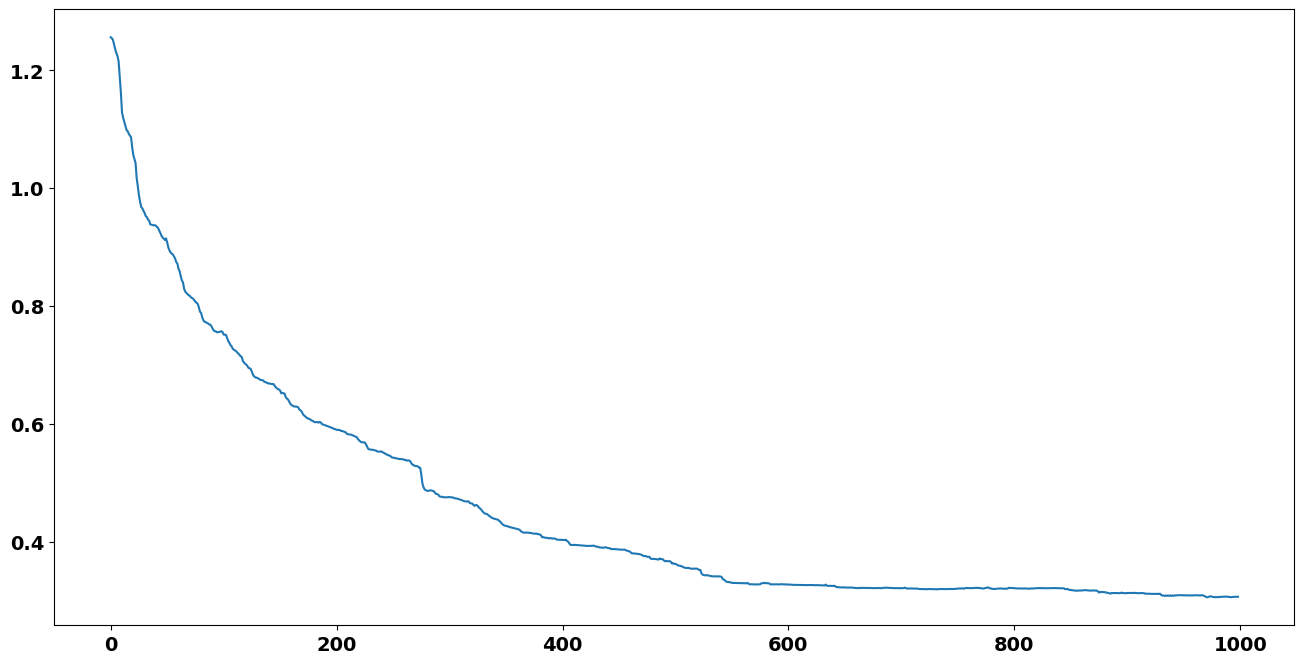

In [ ]:
plt.plot(q_errors)

We could stop training around 600 iterations but, to be on the safe side, we'll use 1000 epochs.

In [ ]:
# Setting up the same som again and retraining it
som = MiniSom(
    15, 15, 6, sigma=0.5,
    learning_rate=1, neighborhood_function='gaussian', random_seed=42)
som.train(scaled_data, 1000)

Now, I would like to investigate how companies' industries divide themselves on our self-organizing map. First, let's create a list with all the industries in our data.

In [ ]:
sectors = list(financial_valuation_data.Sector.unique())
print(sectors)

['Industrials', 'Health Care', 'Information Technology', 'Consumer Discretionary', 'Utilities', 'Financials', 'Materials', 'Real Estate', 'Consumer Staples', 'Energy', 'Telecommunication Services']


We have 11 industries (or sectors, as the dataframe calls them):
*  'Industrials'
*  'Health Care'
*  'Information Technology'
*  'Consumer Discretionary'
*  'Utilities'
*  'Financials'
*  'Materials'
*  'Real Estate'
*  'Consumer Staples'
*  'Energy'
*  'Telecommunication Services'

First, let's see how these industries are scattered across our nodes in the SOM!

We need to understand what is the neuron that is closest to each data point in our data. We can do this with the `som.winner` function! Let's see an example with the industrial company `3M`:

In [ ]:
# Our first company is:
financial_valuation_data.iloc[0]

,0
Symbol,MMM
Name,3M Company
Sector,Industrials
Price,222.89
Price/Earnings,24.31
Dividend Yield,2.332862
Earnings/Share,7.92
52 Week Low,259.77
52 Week High,175.49
Market Cap,138721055226


In [ ]:
# This company is represented by the following scaled data:
scaled_data[0]

array([-0.01209682,  0.28450258,  0.73305718,  0.12976765, -0.03475684,
        0.00262342])

If I now pass the `scaled_data` inside our `som.winner`, I'll have as a return the node that is closest to this point in our lattice (lattice is a fancy word for our grid of nodes)!

In [ ]:
som.winner(scaled_data[0])

(np.int64(2), np.int64(11))

This point is closest to the node that sits in the 2nd index of the x-axis and in the 11th index of the y-axis! Let's see where the second data point lies:

In [ ]:
som.winner(scaled_data[1])

(np.int64(2), np.int64(13))

We can get an overview of how industries split themselves on our SOM by finding the winner node for all data points:

In [ ]:
financial_valuation_data['winner_node'] = (
    [som.winner(scaled_data[i]) for i in range(0, len(scaled_data))]
)

Now, we have a data frame that contains a column with the `winner_node` for each row:

In [ ]:
financial_valuation_data

,Symbol,Name,Sector,Price,Price/Earnings,Dividend Yield,Earnings/Share,52 Week Low,52 Week High,Market Cap,EBITDA,Price/Sales,Price/Book,SEC Filings,Volatility,winner_node
0,MMM,3M Company,Industrials,222.89,24.31,2.332862,7.92,259.77,175.490,138721055226,9.048000e+09,4.390271,11.34,http://www.sec.gov/cgi-bin/browse-edgar?action...,-0.480255,"(2, 11)"
1,AOS,A.O. Smith Corp,Industrials,60.24,27.76,1.147959,1.70,68.39,48.925,10783419933,6.010000e+08,3.575483,6.35,http://www.sec.gov/cgi-bin/browse-edgar?action...,-0.397854,"(2, 13)"
2,ABT,Abbott Laboratories,Health Care,56.27,22.51,1.908982,0.26,64.60,42.280,102121042306,5.744000e+09,3.740480,3.19,http://www.sec.gov/cgi-bin/browse-edgar?action...,-0.527909,"(10, 10)"
3,ABBV,AbbVie Inc.,Health Care,108.48,19.41,2.499560,3.29,125.86,60.050,181386347059,1.031000e+10,6.291571,26.14,http://www.sec.gov/cgi-bin/browse-edgar?action...,-1.095920,"(3, 7)"
4,ACN,Accenture plc,Information Technology,150.51,25.47,1.714470,5.44,162.60,114.820,98765855553,5.643228e+09,2.604117,10.62,http://www.sec.gov/cgi-bin/browse-edgar?action...,-0.416130,"(13, 8)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
500,XYL,Xylem Inc.,Industrials,70.24,30.94,1.170079,1.83,76.81,46.860,12915021000,7.220000e+08,2.726209,5.31,http://www.sec.gov/cgi-bin/browse-edgar?action...,-0.639138,"(7, 4)"
501,YUM,Yum! Brands Inc,Consumer Discretionary,76.30,27.25,1.797080,4.07,86.93,62.850,27003303098,2.289000e+09,6.313636,212.08,http://www.sec.gov/cgi-bin/browse-edgar?action...,-0.383134,"(11, 5)"
502,ZBH,Zimmer Biomet Holdings,Health Care,115.53,14.32,0.794834,9.01,133.49,108.170,24454698119,2.007400e+09,3.164895,2.39,http://www.sec.gov/cgi-bin/browse-edgar?action...,-0.234076,"(10, 11)"
503,ZION,Zions Bancorp,Financials,50.71,17.73,1.480933,2.60,55.61,38.430,10670678640,0.000000e+00,3.794579,1.42,http://www.sec.gov/cgi-bin/browse-edgar?action...,-0.447047,"(2, 13)"


We can do some cool stuff - for example, seeing how many companies belong to each node or what's the most representative industry in the neuron.

In [ ]:
financial_valuation_data.groupby('winner_node').size().sort_values()

,0
winner_node,
"(2, 0)",1
"(2, 3)",1
"(3, 6)",1
"(7, 11)",1
"(7, 12)",1
...,...
"(2, 13)",10
"(7, 2)",12
"(12, 5)",12


The neurons with the most data points associated are neurons:
- 10, 6
- 5, 5
- 7, 2
- 12, 5
- 8, 10

Also, we can check what's the most represented industry in each node:

In [ ]:
top_industries = (
    financial_valuation_data.groupby(['winner_node', 'Sector'], as_index=False)
    .size()
    .sort_values(by='size')
    .groupby(['winner_node'])
    .tail(1)
)

In [ ]:
top_industries

,winner_node,Sector,size
19,"(1, 1)",Information Technology,1
23,"(1, 4)",Industrials,1
279,"(13, 6)",Real Estate,1
38,"(2, 0)",Consumer Discretionary,1
42,"(2, 1)",Materials,1
...,...,...,...
123,"(5, 5)",Consumer Discretionary,5
162,"(7, 4)",Consumer Discretionary,5
63,"(3, 2)",Consumer Discretionary,6
157,"(7, 2)",Real Estate,12


Why do we only have 111 rows? **Because some nodes do not have any data point assigned to them!**

Now, let's build a 15 by 15 grid that will represent our lattice:

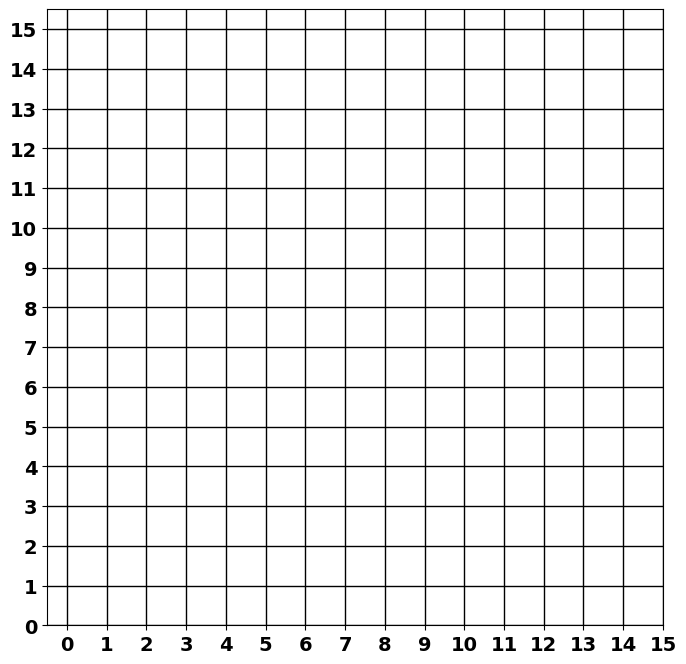

In [ ]:
build_lattice(15, 15)

Let's represent each node with a color related to the sector with more representation.

In [ ]:
industry_color = {sector: 'C'+str(i+1) for i, sector in enumerate(sectors)}

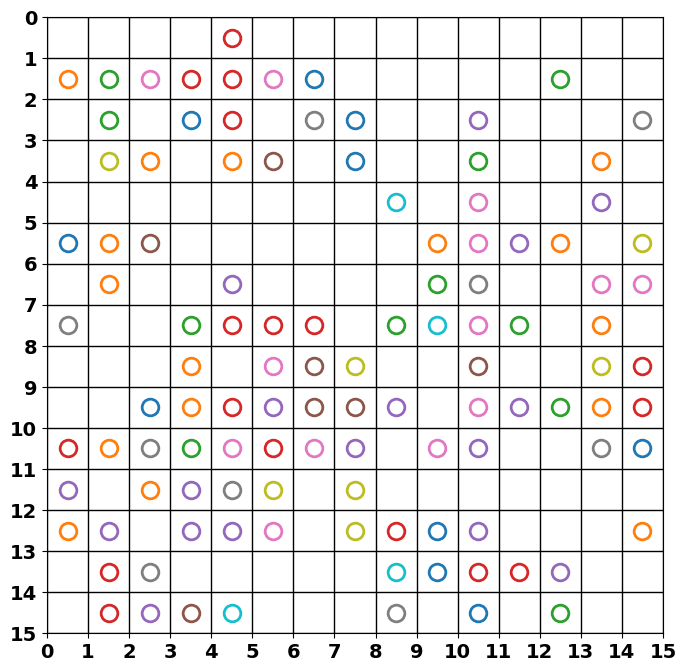

In [ ]:
build_lattice(15, 15)

for index, row in top_industries.iterrows():
    # Print the row data
    plt.plot(row.winner_node[0]+0.5, row.winner_node[1]+0.5,
             'o', markerfacecolor='None',
            markeredgecolor=industry_color[row.Sector],
            markersize=12, markeredgewidth=2)
    plt.xlim(0, 15)
    plt.ylim(0, 15)

# Show the plot
plt.show()

Each color, represents an industry. In each point of the grid we have the most representative industries for that specific neuron.
<br>
Unfortunately, doesn't seem that we can cluster our data points in terms of industry 😞

The best "condensed points" are the yellow ones that refer the `Real Estate` industry, as we will see below.

Another common way to visualize a self-organizing map is to see the `distance_map`, a high level representation that shows the distance between nodes:

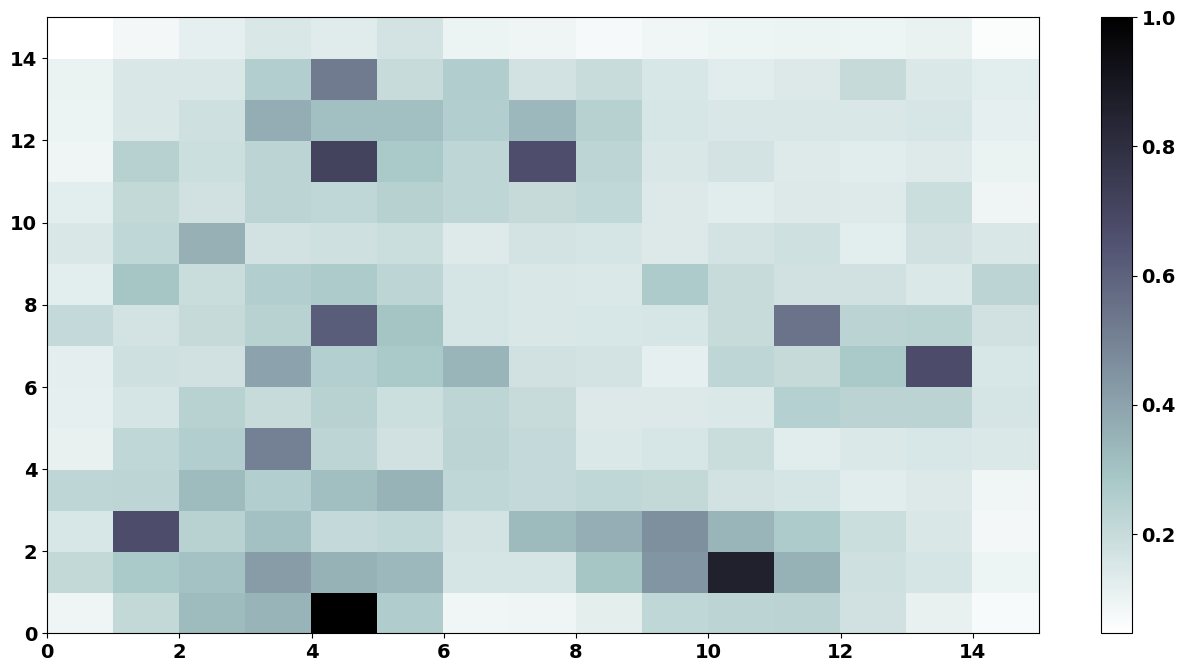

In [ ]:
# Distance map of our nodes
plt.pcolor(som.distance_map().T, cmap='bone_r')
plt.colorbar()

Darker nodes are nodes that sit far apart in our `lattice`. This will be specially helpful when we want to filter some outliers, as we will see in a couple of minutes!

Let's also visualize our individual data points in the grid:

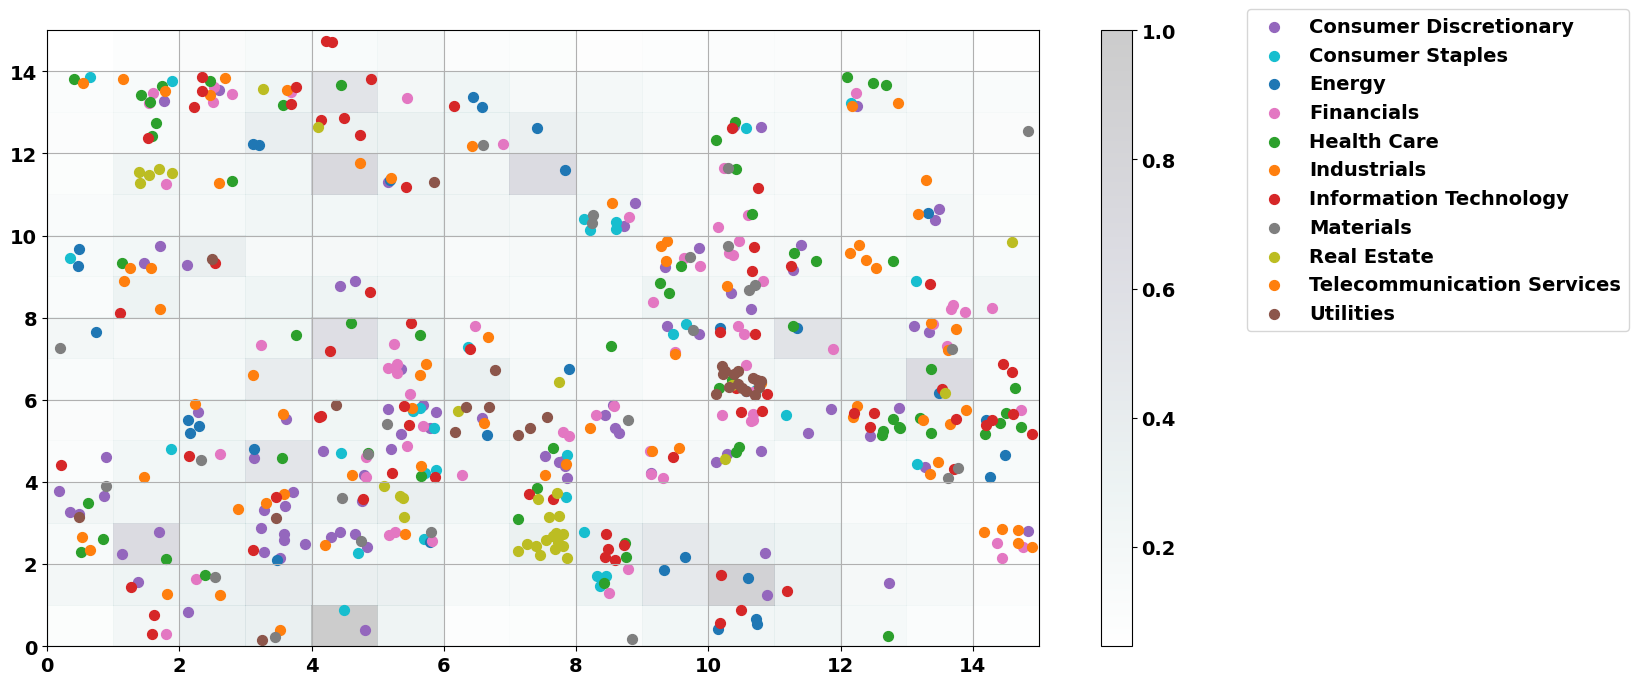

In [ ]:
visualize_data_points_grid(
    financial_valuation_data, scaled_data, som, 'Sector',industry_color
)

Can you guess what's the industry what are the industries that our SOM is able to bundle together using these variables?

![discuss](https://cdn-icons-png.flaticon.com/512/1189/1189168.png)

Spoiler:

- `Real Estate`
- `Utilities`

We can also try to use our SOM as a Classification algorithm (although if we want to evaluate this cleanly, we need a train test split!):

Basically, in this example, we are predicting the most representative class in each node as the target. Let's see how good is our model:

In [ ]:
prediction = classify(som, scaled_data, financial_valuation_data)

In [ ]:
print(classification_report(financial_valuation_data.Sector, classify(som, scaled_data, financial_valuation_data)))

                            precision    recall  f1-score   support

    Consumer Discretionary       0.50      0.63      0.56        84
          Consumer Staples       0.35      0.41      0.38        34
                    Energy       0.61      0.62      0.62        32
                Financials       0.52      0.43      0.47        68
               Health Care       0.45      0.39      0.42        61
               Industrials       0.49      0.43      0.46        67
    Information Technology       0.48      0.46      0.47        70
                 Materials       0.44      0.28      0.34        25
               Real Estate       0.79      0.82      0.81        33
Telecommunication Services       1.00      0.33      0.50         3
                 Utilities       0.55      0.79      0.65        28

                  accuracy                           0.51       505
                 macro avg       0.56      0.51      0.51       505
              weighted avg       0.51      0.5

We can also use our Self-Organizing Map to visualize how features are interacting with our nodes!

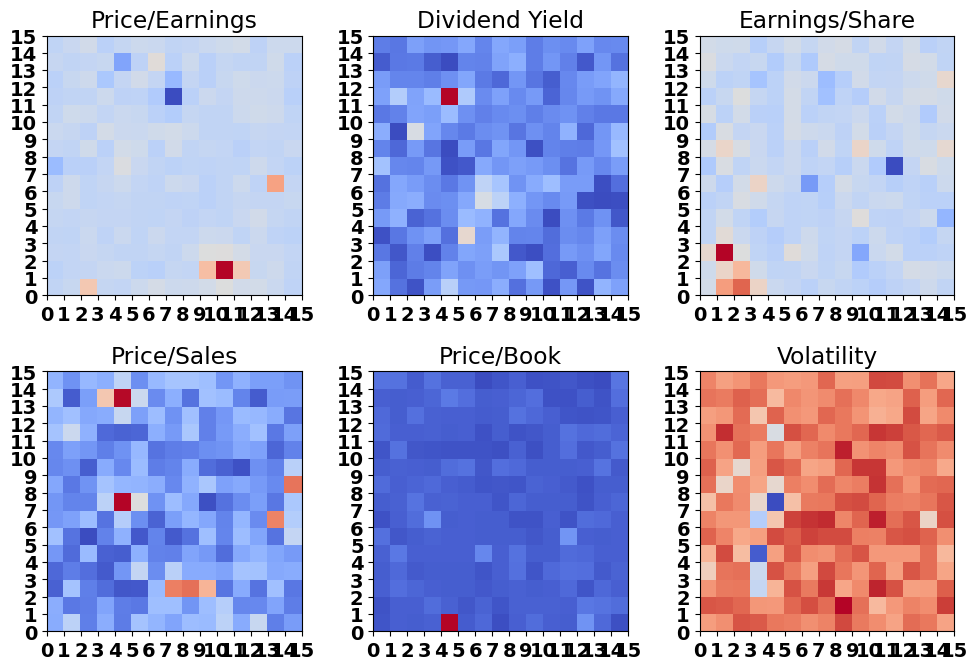

In [ ]:
plot_feature_influence(som, financial_valuation_data_subset)

Red values mean that the specific node has a high positive influence from that feature (the value is really high when you compared it with the mean.. sounds similar to k-means?)
<br>
<br>
Let's investigate some things about our features. For example, let's analyze a node that contains a really high Price-to-Earnings value:

In [ ]:
(
    financial_valuation_data
    .loc[financial_valuation_data['winner_node']
         .apply(lambda x: (x[0] == 10) & (x[1] == 1))]
)

,Symbol,Name,Sector,Price,Price/Earnings,Dividend Yield,Earnings/Share,52 Week Low,52 Week High,Market Cap,EBITDA,Price/Sales,Price/Book,SEC Filings,Volatility,winner_node
30,AMZN,Amazon.com Inc,Consumer Discretionary,1350.50,296.16,0.000000,6.16,1498.00,812.50,685873374731,1.613200e+10,3.927053,24.28,http://www.sec.gov/cgi-bin/browse-edgar?action...,-0.843692,"(10, 1)"
64,BHGE,"Baker Hughes, a GE Company",Energy,27.50,305.56,2.499132,-0.31,57.73,28.03,32995712852,2.850000e+08,1.939005,2.25,http://www.sec.gov/cgi-bin/browse-edgar?action...,-1.059579,"(10, 1)"
403,CRM,Salesforce.com,Information Technology,104.03,520.15,0.000000,0.27,114.52,79.63,79489115000,9.258040e+08,10.373879,8.81,http://www.sec.gov/cgi-bin/browse-edgar?action...,-0.438151,"(10, 1)"


On the opposite side, node 7-11 has a really low influence of Price/Earnings:

In [ ]:
(
    financial_valuation_data
    .loc[financial_valuation_data['winner_node']
         .apply(lambda x: (x[0] == 7) & (x[1] == 11))]
)

,Symbol,Name,Sector,Price,Price/Earnings,Dividend Yield,Earnings/Share,52 Week Low,52 Week High,Market Cap,EBITDA,Price/Sales,Price/Book,SEC Filings,Volatility,winner_node
49,APA,Apache Corporation,Energy,37.73,-251.53,2.528445,-3.72,57.9,38.14,15066280977,3.265000e+09,3.651366,2.22,http://www.sec.gov/cgi-bin/browse-edgar?action...,-0.518091,"(7, 11)"


Let's also check the same analysis for nodes with influence from Dividend Yield:

In [ ]:
(
    financial_valuation_data
    .loc[financial_valuation_data['winner_node']
         .apply(lambda x: (x[0] == 4) & (x[1] == 11))]
)

,Symbol,Name,Sector,Price,Price/Earnings,Dividend Yield,Earnings/Share,52 Week Low,52 Week High,Market Cap,EBITDA,Price/Sales,Price/Book,SEC Filings,Volatility,winner_node
99,CTL,CenturyLink Inc,Telecommunication Services,16.2,8.35,12.661196,1.16,27.61,13.161,18237196861,5.577000e+09,1.479598,1.39,http://www.sec.gov/cgi-bin/browse-edgar?action...,-1.097865,"(4, 11)"


In [ ]:
(
    financial_valuation_data
    .loc[financial_valuation_data['winner_node']
         .apply(lambda x: (x[0] == 4) & (x[1] == 8))]
)

,Symbol,Name,Sector,Price,Price/Earnings,Dividend Yield,Earnings/Share,52 Week Low,52 Week High,Market Cap,EBITDA,Price/Sales,Price/Book,SEC Filings,Volatility,winner_node
106,CMG,Chipotle Mexican Grill,Consumer Discretionary,266.01,45.86,0.0,0.80,499.00,263.00,7685283970,4.012930e+08,2.552385,6.11,http://www.sec.gov/cgi-bin/browse-edgar?action...,-0.897338,"(4, 8)"
355,PYPL,PayPal,Information Technology,72.32,49.53,0.0,1.47,86.32,39.92,90708000000,2.932000e+09,6.935696,5.81,http://www.sec.gov/cgi-bin/browse-edgar?action...,-1.162325,"(4, 8)"
451,TRIP,TripAdvisor,Consumer Discretionary,40.05,58.04,0.0,0.81,53.29,29.50,5700998508,2.340000e+08,4.592577,3.49,http://www.sec.gov/cgi-bin/browse-edgar?action...,-0.806441,"(4, 8)"


Finally, let's see the most important variables for each node- this is done by checking the maximum weight in each node. We can only do this because features are on the same scale!

/content/utils.py:204: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  plt.plot([i+.5], [j+.5], 'o', color='C'+str(feature),


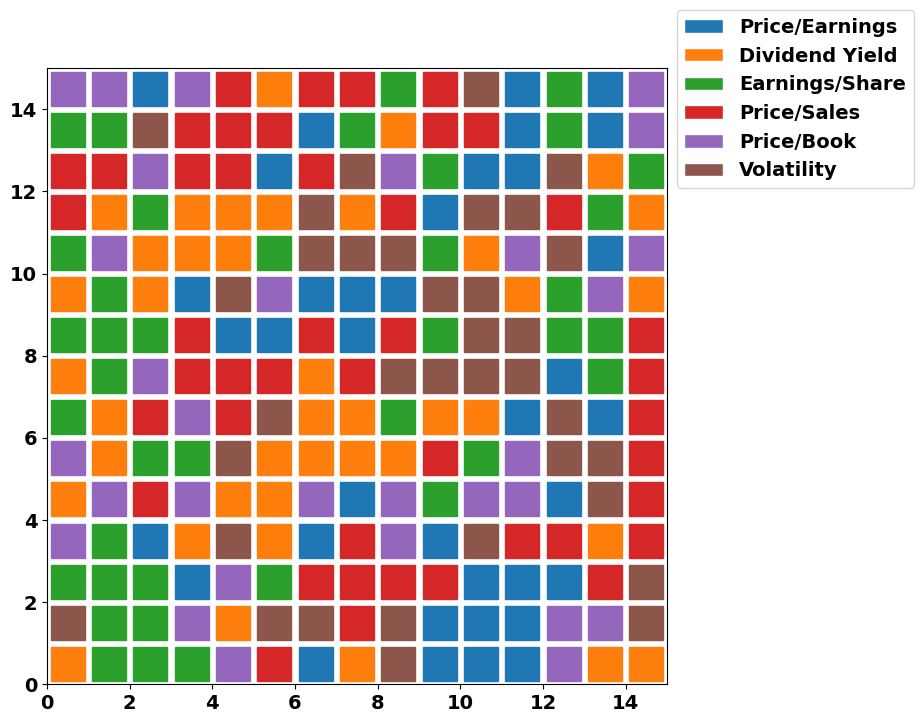

In [ ]:
plot_most_important_variable(som, financial_valuation_data_subset.columns)

Let's see an example of companies that have a lot of influence of Earning per Share - node `2-1`:

In [ ]:
(
    financial_valuation_data
    .loc[financial_valuation_data['winner_node']
         .apply(lambda x: (x[0] == 2) & (x[1] == 1))]
)

,Symbol,Name,Sector,Price,Price/Earnings,Dividend Yield,Earnings/Share,52 Week Low,52 Week High,Market Cap,EBITDA,Price/Sales,Price/Book,SEC Filings,Volatility,winner_node
178,RE,Everest Re Group Ltd.,Financials,241.06,27.24,2.107823,23.71,277.1700,208.8100,10131892523,0.000000e+00,2.099199,1.16,http://www.sec.gov/cgi-bin/browse-edgar?action...,-0.327379,"(2, 1)"
302,MCK,McKesson Corp.,Health Care,150.23,11.68,0.889878,22.74,178.8600,133.8200,31534840262,7.232000e+09,0.153186,2.68,http://www.sec.gov/cgi-bin/browse-edgar?action...,-0.336572,"(2, 1)"
338,NSC,Norfolk Southern Corp.,Industrials,136.89,20.65,2.018503,18.73,157.1499,109.2700,40543547441,4.737000e+09,3.852591,3.09,http://www.sec.gov/cgi-bin/browse-edgar?action...,-0.438180,"(2, 1)"
411,SHW,Sherwin-Williams,Materials,387.65,26.75,0.842669,18.61,435.1500,302.0101,37730994828,2.160668e+09,2.527608,13.42,http://www.sec.gov/cgi-bin/browse-edgar?action...,-0.440846,"(2, 1)"


What's the mean of Earnings per Share?

In [ ]:
financial_valuation_data['Earnings/Share'].mean()

np.float64(3.7537425742574255)

As you can see, Self-Organizing Maps are very useful to understand the underlying structure of our data. Particularly, for datasets with a couple of dimensions, the visualization we can do with a SOM are very interesting and can provide us an interesting overview of a dataset in a quick way.
<br>
<br>
As usual, let's practice this with exercises!

# Exercise Section

### Exercise 1
<br>
Load the `airline_customers.csv` file into a dataframe named `airline`.

In [ ]:
### YOUR CODE HERE

### Exercise 2
Subset all numerical columns from the `airline` dataframe. Save the object in a file named `numeric_airline`. From the numeric columns, also discard `Unnamed: 0` and `id`.

In [ ]:
### YOUR CODE HERE

### Exercise 3
Standardize the `numeric_airline` dataframe and store it in an object named `scaled_data_airline`. Use `StandardScaler`.
<br>
Fill all `na` values with 0.

In [ ]:
### YOUR CODE HERE

### Exercise 4
Train a Self Orgaining Map on the `scaled_data_airline` with the following parameters:
*   5 by 5 Grid.
*   Sigma = 0.2.
*   Learning_Rate = 0.2.
*   Neighborhood function should be gaussian.
*   Random Seed as 1
*   Train for 2000 iterations

Save the trained model in an object called `som_airline`.

In [ ]:
### YOUR CODE HERE

### Exercise 5
Plot the distance map of `som_airline`. Which nodes (top 4) seem to be more distant from the rest of the lattice? (Consider that nodes start on index 0)

In [ ]:
### YOUR CODE HERE

- Answer:

###  Exercise 6
Plot the data points along the grid using `satisfaction` as a color for the scatters. Do you see any particular pattern?
<br>
*hint: use the code we've used on the practical example!*
<br>
*hint 2: use the dictionary `satisfaction_mapping`!*

In [ ]:
satisfaction_mapping = {
    'neutral or dissatisfied' : 'red',
    'satisfied' : 'green'
}

In [ ]:
### YOUR CODE HERE

Answer:

### Exercise 7
What are the variables that influences more nodes in the SOM?
<br>
You can use the color mapping (`feature_colors` dictionary) I provide below.
<br>
<br>
*hint: use the code we've used during the practical example to understand the most important variable!*

In [ ]:
import random
from matplotlib import colors

feature_names = numeric_airline.columns
feature_colors = {}

for i, feature in enumerate(feature_names):
  random_color = colors.to_rgba(colors.rgb2hex(np.random.rand(3)))
  feature_colors[i] = random_color

In [ ]:
### YOUR CODE HERE

- Answer:

### Exercise 8
For node (0,2) what's the variable with most influence?

-

### Exercise 9
Add a new column called `winner_node` to the `numeric_airline` dataframe. This column should contain the node that is nearer each data point.
<br>
*Hint: Use the `som_airline.winner` function!*

In [ ]:
### YOUR CODE HERE

### Exercise 10
Subset all examples, where the `winner_node` is equal to (4,4). Named the filtered dataframe `node_4_4`.

In [ ]:
### YOUR CODE HERE

### Exercise 11
The variable with most impact on the node 4,4 is "Food and Drink". Do these customers gave more points to food and drink than the average, i.e., is this a positive impact?

In [ ]:
### YOUR CODE HERE

-

### Exercise 12
Some customers were extremely unhappy with their Inflight Wifi Service. Can you guess which node(s) they belong to by looking at the following feature map?

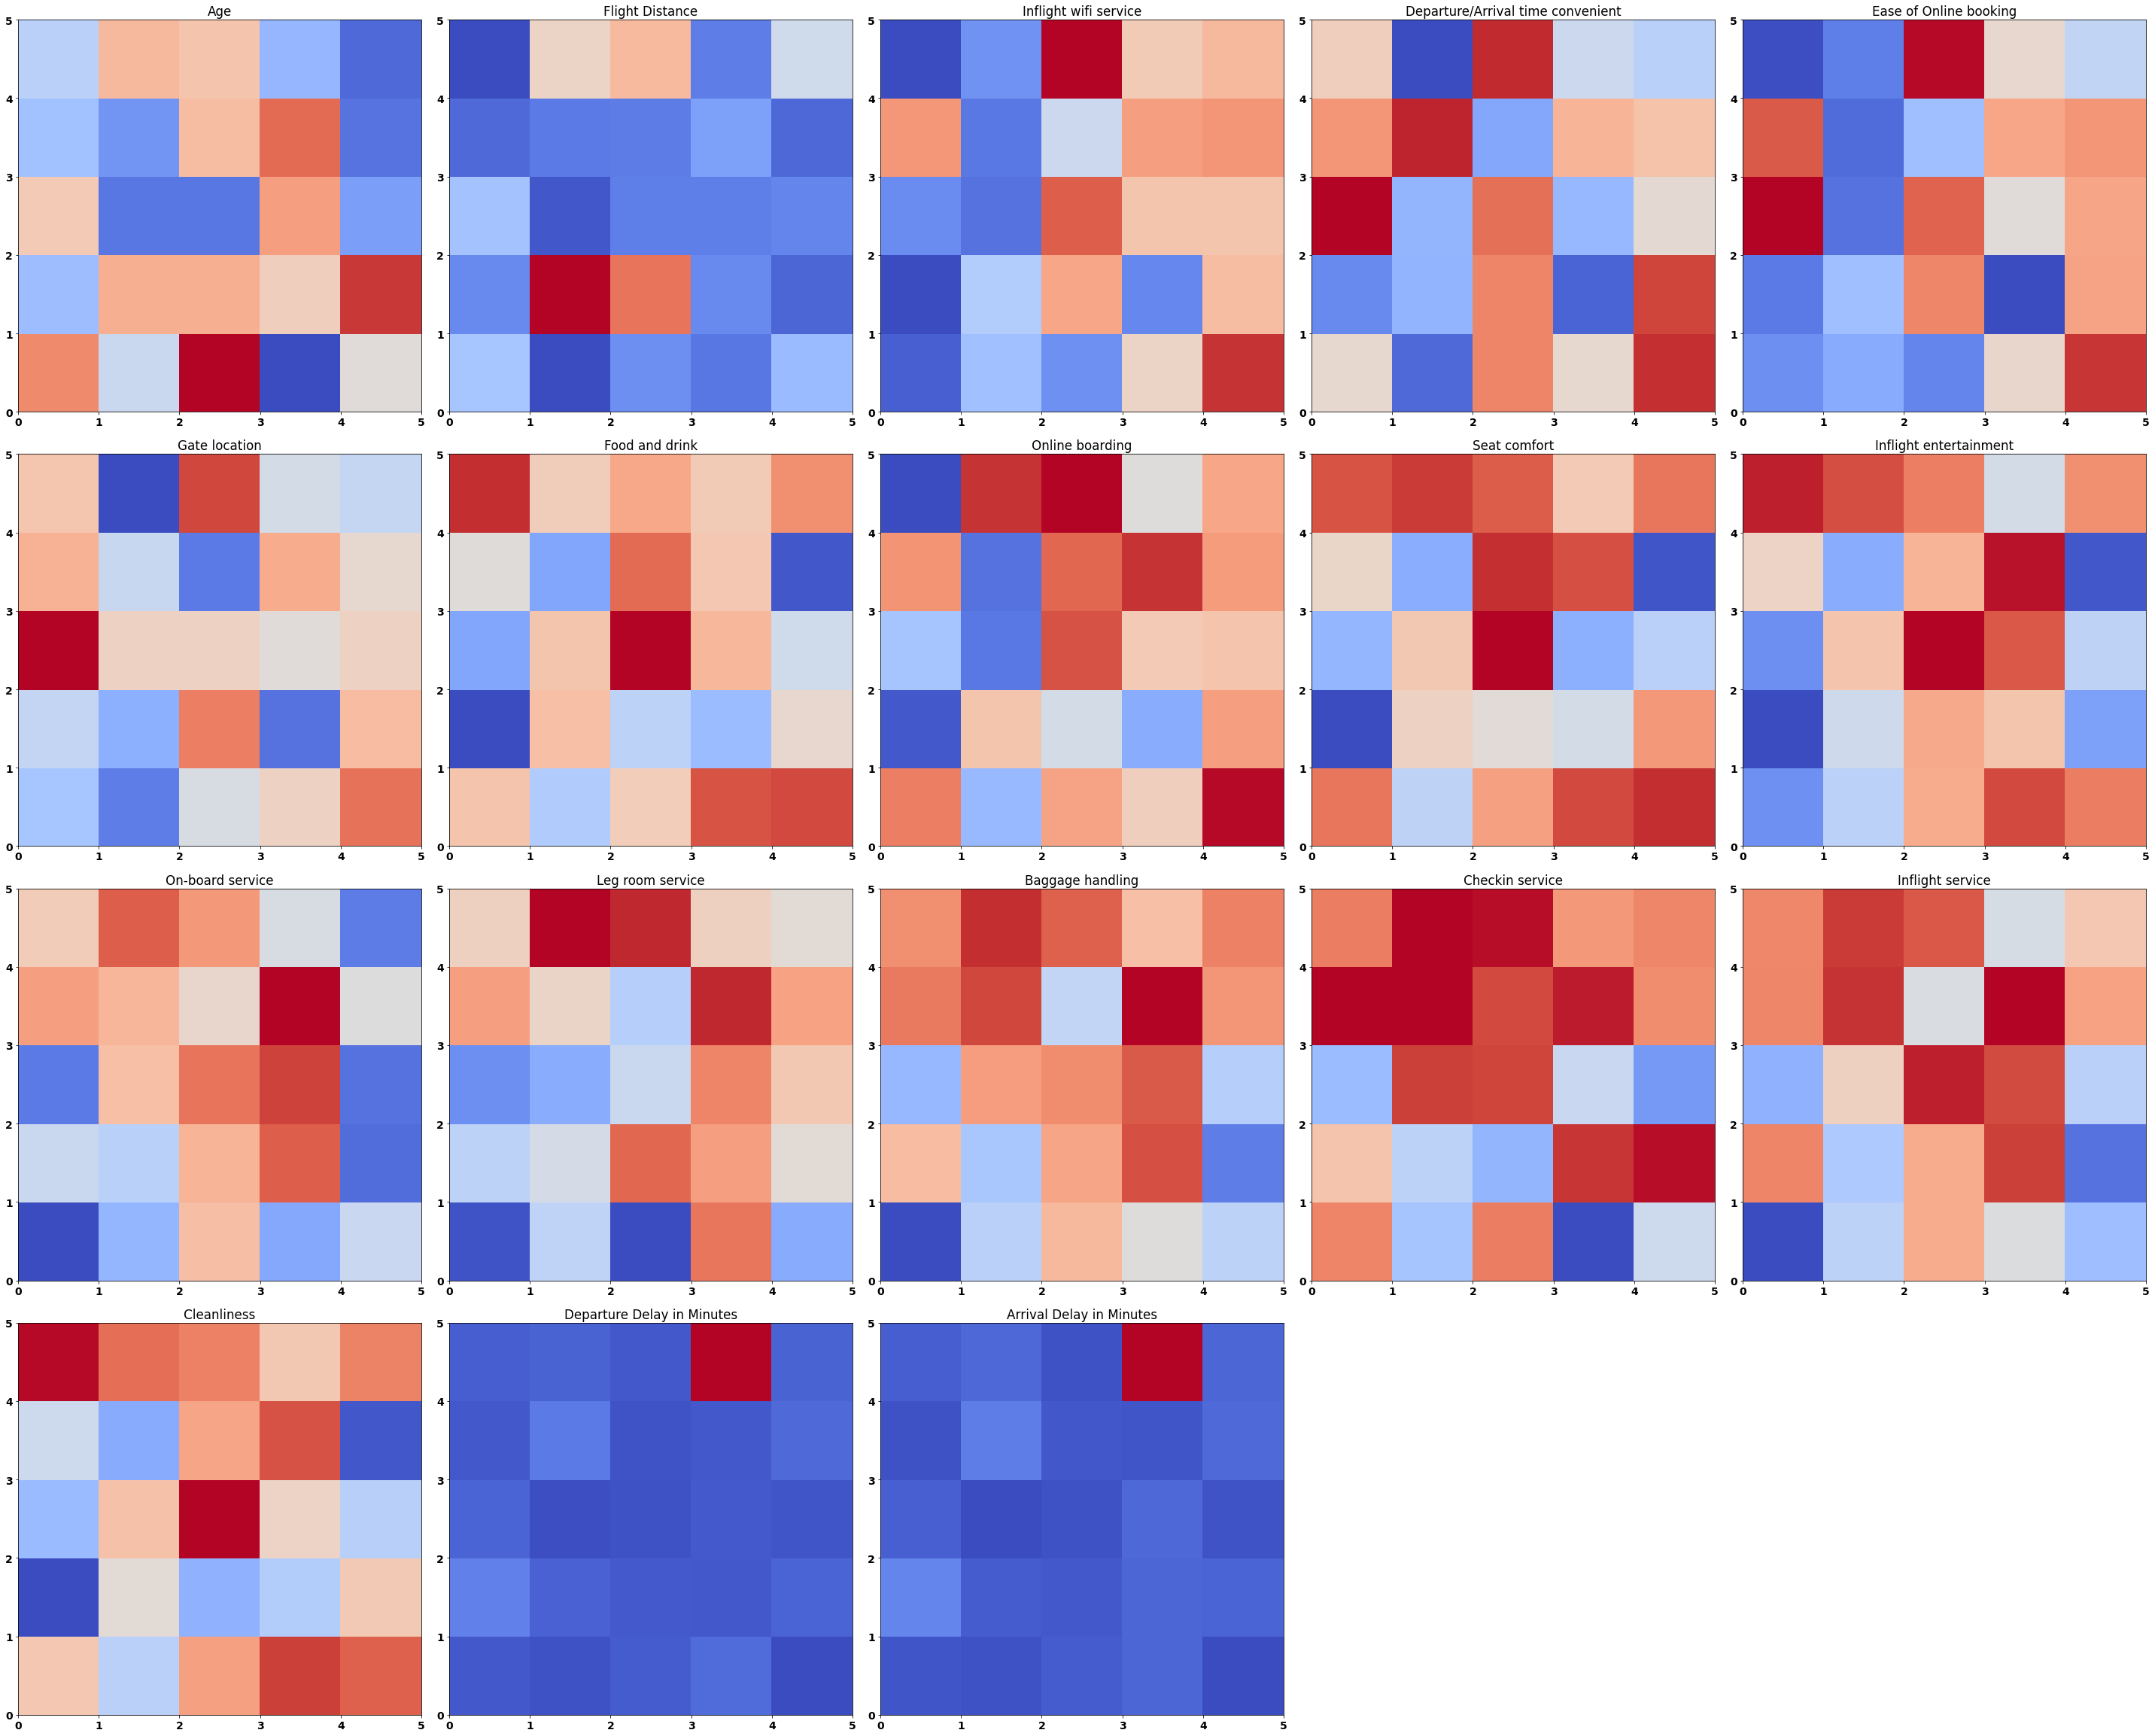

In [ ]:
feature_names = numeric_airline.columns[:-1]
W = som_airline.get_weights()
plt.figure(figsize=(40, 40))
for i, f in enumerate(feature_names):
    plt.subplot(5, 5, i+1)
    plt.title(f)
    plt.pcolor(W[:,:,i].T, cmap='coolwarm')
    plt.xticks(np.arange(5+1))
    plt.yticks(np.arange(5+1))
plt.tight_layout()
plt.show()

-

### Exercise 13
Of the groups we've mentioned above, which customers seem more unhappy, in general?

-

### Exercise 14
Could this SOM be a good way to classify Loyal vs. Unloyal Customers (`Customer Type` variable)? *Hint: Use the `classify` function we've used in the lectures!*

In [ ]:
### YOUR CODE HERE

Answer: